200
201
Overall error as x increases: [0. 0. 0. ... 0. 0. 0.]
Total Error: 0.0


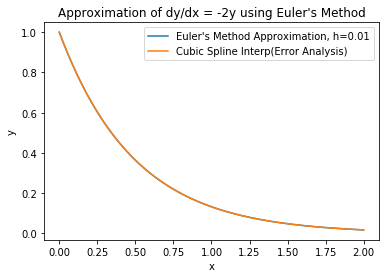

33
34
Overall error as x increases: [0.00000000e+00 4.60669556e-06 9.21679357e-06 ... 2.86867468e-03
 2.86796538e-03 2.86725614e-03]
Total Error: 0.0


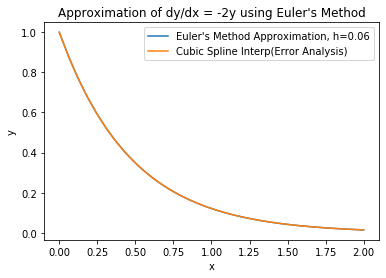

18
19
Overall error as x increases: [0.00000000e+00 1.36124966e-05 2.72286936e-05 ... 6.17033228e-03
 6.16865628e-03 6.16698035e-03]
Total Error: 0.01


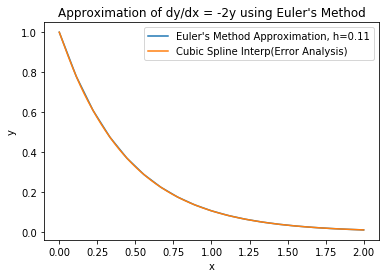

12
13
Overall error as x increases: [0.00000000e+00 1.01548741e-05 2.03135833e-05 ... 7.81742270e-03
 7.81529506e-03 7.81316749e-03]
Total Error: 0.01


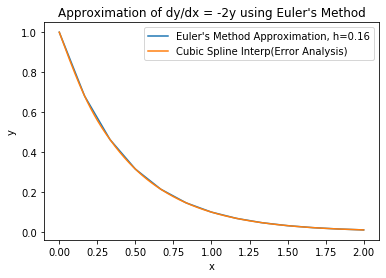

9
10
Overall error as x increases: [0.00000000e+00 1.31219271e-05 2.62477511e-05 ... 1.01661856e-02
 1.01632367e-02 1.01602879e-02]
Total Error: 0.01


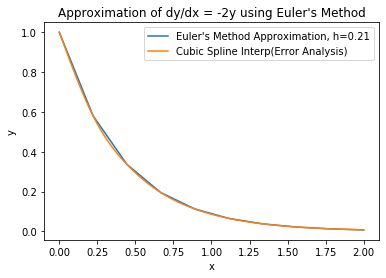

7
8
Overall error as x increases: [0.00000000e+00 7.24121311e-06 1.44863699e-05 ... 1.17242734e-02
 1.17207682e-02 1.17172632e-02]
Total Error: 0.0


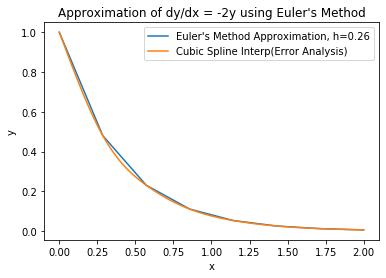

6
7
Overall error as x increases: [0.00000000e+00 2.63946182e-05 5.27931910e-05 ... 1.45871455e-02
 1.45820778e-02 1.45770102e-02]
Total Error: 0.01


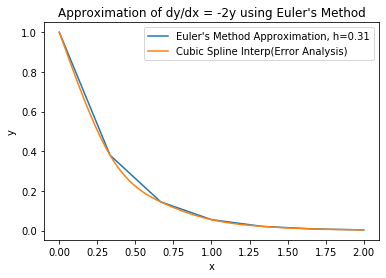

5
6
Overall error as x increases: [0.00000000e+00 2.29087926e-05 4.58215642e-05 ... 1.58772111e-02
 1.58720604e-02 1.58669098e-02]
Total Error: 0.01


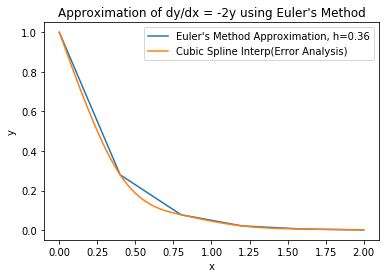

4
5
Overall error as x increases: [0.00000000e+00 4.95718947e-06 9.91036906e-06 ... 1.65560165e-02
 1.65471015e-02 1.65381866e-02]
Total Error: 0.0


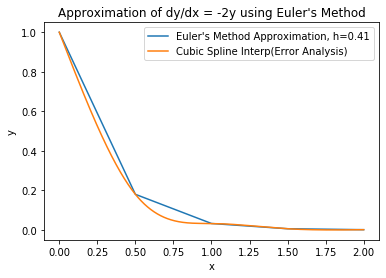

4
5
Overall error as x increases: [0.00000000e+00 5.50981786e-05 1.10200348e-04 ... 1.75702910e-02
 1.75586388e-02 1.75469866e-02]
Total Error: 0.03


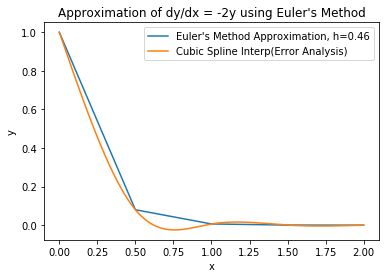

3
4
Overall error as x increases: [0.00000000e+00 1.20501479e-05 2.40962650e-05 ... 1.75650494e-02
 1.75804980e-02 1.75959466e-02]
Total Error: 0.0


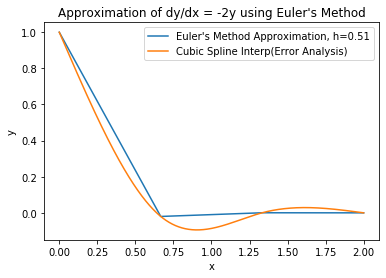

3
4
Overall error as x increases: [0.00000000e+00 3.76692223e-05 7.53424647e-05 ... 1.92462983e-02
 1.92811224e-02 1.93159466e-02]
Total Error: 0.02


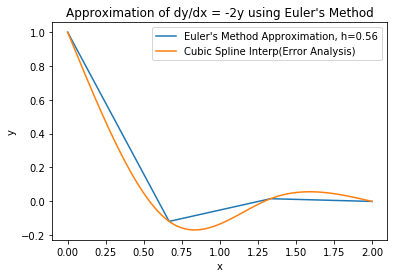

3
4
Overall error as x increases: [0.00000000e+00 8.99328467e-05 1.79869701e-04 ... 2.81028728e-02
 2.81694097e-02 2.82359466e-02]
Total Error: 0.04


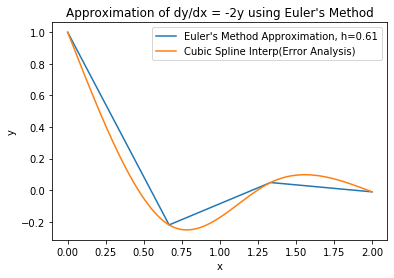

3
4
Overall error as x increases: [0.         0.00014486 0.00028973 ... 0.05013021 0.05024308 0.05035595]
Total Error: 0.06


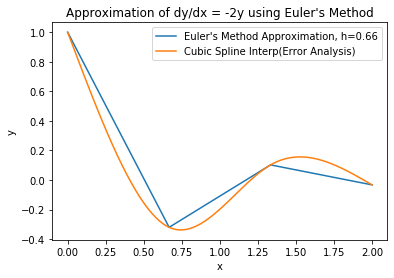

2
3
Overall error as x increases: [0.00000000e+00 1.68787872e-05 3.37535228e-05 ... 1.58357512e-01
 1.58584783e-01 1.58812053e-01]
Total Error: 0.01


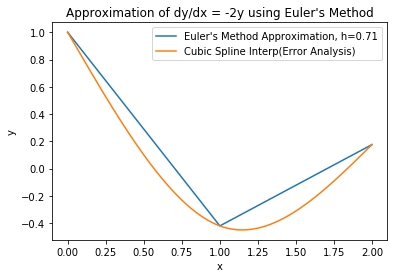

2
3
Overall error as x increases: [0.00000000e+00 1.78246825e-05 3.56534132e-05 ... 2.52250501e-01
 2.52531277e-01 2.52812053e-01]
Total Error: 0.01


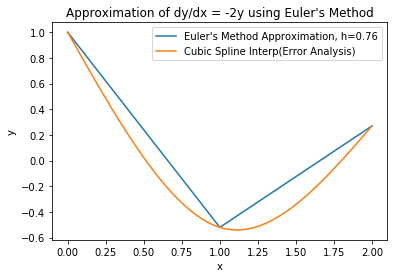

2
3
Overall error as x increases: [0.00000000e+00 5.35282523e-05 1.07060549e-04 ... 3.66133490e-01
 3.66472772e-01 3.66812053e-01]
Total Error: 0.01


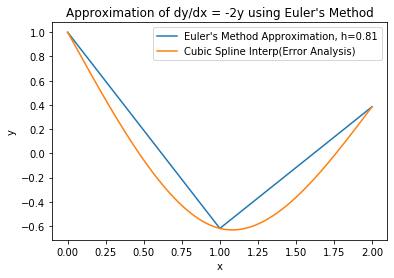

2
3
Overall error as x increases: [0.00000000e+00 9.02319220e-05 1.80467884e-04 ... 5.00006477e-01
 5.00409265e-01 5.00812053e-01]
Total Error: 0.02


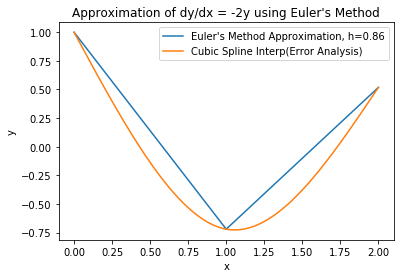

2
3
Overall error as x increases: [0.00000000e+00 1.27935692e-04 2.55875419e-04 ... 6.53869463e-01
 6.54340758e-01 6.54812053e-01]
Total Error: 0.04


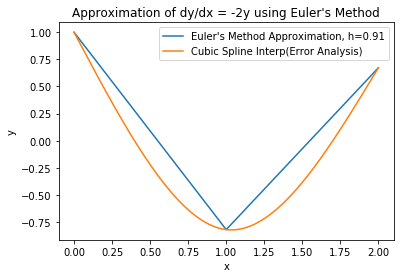

2
3
Overall error as x increases: [0.00000000e+00 1.66639561e-04 3.33283154e-04 ... 8.27722449e-01
 8.28267251e-01 8.28812053e-01]
Total Error: 0.06


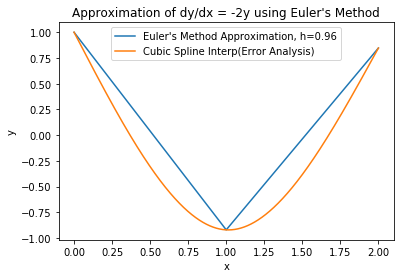

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline


# Define parameters
h = 0.01  # step size

while h<=1:
    x_start, x_end = 0, 2
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1
    # Function representing dy/dx = -2y
    def f(x, y):
        return -2 * y
    print(num_steps)

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
    if(h==0.01):
        y_init = y_values
        cs = CubicSpline(x_values, y_init, bc_type='natural')
        x_interp = np.linspace(0, 2, 10000)
        y_init_interp = cs(x_interp)
    print(len(y_values))
    
    cs = CubicSpline(x_values, y_values, bc_type='natural')
    y_interp = cs(x_interp)
    
    p_by_p_error = np.abs(y_init_interp - y_interp)
    
    print(f"Overall error as x increases: {p_by_p_error}")
    

    
    total_error = np.abs(np.average(y_values)-np.average(y_init))
    print(f"Total Error: {round(total_error, 2)}")
            

    # Plot the results
    plt.plot(x_values, y_values, label=f"Euler's Method Approximation, h={round(h, 2)}")
    plt.plot(x_interp, y_interp, label="Cubic Spline Interp(Error Analysis)")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title("Approximation of dy/dx = -2y using Euler's Method")
    plt.legend()
    plt.show()
    h +=0.05